In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "3,"
from pathlib import Path
import pickle as pkl
import json, zipfile, shutil
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import cv2
from PIL import Image
import torch
from diffusers import FluxFillPipeline
from diffusers import ControlNetModel, StableDiffusionControlNetInpaintPipeline
from diffusers import FluxControlNetModel, FluxControlNetInpaintPipeline
from diffusers.utils import load_image
from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX

from nunchaku import NunchakuFluxTransformer2dModel
from nunchaku.utils import get_precision

In [2]:
# # SD1.5 inpaint + OpenPose ControlNet (equivalent setup)

# controlnet = ControlNetModel.from_pretrained(
#     "lllyasviel/control_v11p_sd15_openpose",
#     dtype=torch.float16,
# )

# pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
#     "runwayml/stable-diffusion-inpainting",
#     controlnet=controlnet,
#     dtype=torch.float16,
# ).to('cuda')

# pipe.enable_xformers_memory_efficient_attention()  # optional if installed


In [3]:
TRANSFORMER_ID = "nunchaku-tech/nunchaku-flux.1-fill-dev/svdq-int4_r32-flux.1-fill-dev.safetensors"  # change if needed
# OPENPOSE_CONTROLNET_ID = "Shakker-Labs/FLUX.1-dev-ControlNet-Union-Pro"  # change if needed

precision = get_precision()  # auto-detect your precision is 'int4' or 'fp4' based on your GPU
transformer = NunchakuFluxTransformer2dModel.from_pretrained(
    TRANSFORMER_ID
)
pipe = FluxFillPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-Fill-dev", transformer=transformer, torch_dtype=torch.bfloat16
).to("cuda")

# controlnet = FluxControlNetModel.from_pretrained(
#     OPENPOSE_CONTROLNET_ID,
#     torch_dtype=torch.bfloat16,
# )
# pipe = FluxControlNetInpaintPipeline.from_pretrained(
#     "black-forest-labs/FLUX.1-Fill-dev",
#     transformer=transformer,
#     controlnet=controlnet,
#     torch_dtype=torch.bfloat16,
# ).to("cuda")


[2026-02-17 13:02:30.490] [info] Initializing QuantizedFluxModel on device 0
Injecting quantized module
[2026-02-17 13:02:30.739] [info] Loading partial weights from pytorch
[2026-02-17 13:02:32.616] [info] Done.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


In [12]:
dataset_dir = Path("samples/debug/3dpw_debug")
output_dir = Path("outputs/debug/3dpw_debug")

target_img_name = "downtown_bar_00_0_369_112.png"
vid = "_".join(target_img_name.split("_")[:4])
i = int(target_img_name.split("_")[4])
control_img_name = "_".join(target_img_name.split("_")[:5]) + f"_openpose.png"

target_frame = Image.open(output_dir / target_img_name)
control_frame = Image.open(output_dir / control_img_name)

batch = torch.load(dataset_dir / f"{vid}_batch.pt")

In [ ]:
dataset_dir = Path("samples/debug/emdb_debug")
output_dir = Path("outputs/debug/emdb_debug")

target_img_name = "P6_50_outdoor_workout_866_325.png"
vid = "_".join(target_img_name.split("_")[:4])
i = int(target_img_name.split("_")[4])
control_img_name = "_".join(target_img_name.split("_")[:5]) + f"_openpose.png"

target_frame = Image.open(output_dir / target_img_name)
control_frame = Image.open(output_dir / control_img_name)

batch = torch.load(dataset_dir / f"{vid}_batch.pt")

In [5]:
def mask_bbox_from_keypoints(keypoints, image_size, conf_thresh=0.85, margin=32):
    """
    keypoints: np.ndarray (N, 3) => [x, y, conf]
    image_size: (width, height)
    Returns (bbox, direction) where bbox is [x1, y1, x2, y2].
    Masks a single side (top/left/bottom/right) to cover as many
    low-confidence keypoints as possible with minimal area.
    """
    w, h = image_size
    kp = np.asarray(keypoints, dtype=np.float32)
    if kp.ndim != 2 or kp.shape[1] != 3:
        raise ValueError(f"Expected keypoints shape (N, 3), got {kp.shape}")

    low = kp[kp[:, 2] < conf_thresh]
    if low.size == 0:
        return None, None  # nothing to mask

    xs = np.clip(low[:, 0], 0, w)
    ys = np.clip(low[:, 1], 0, h)

    def choose_best(candidates):
        best = None
        for count, area, bbox, direction in candidates:
            if best is None:
                best = (count, area, bbox, direction)
                continue
            if count > best[0] or (count == best[0] and area < best[1]):
                best = (count, area, bbox, direction)
        return best

    def best_top():
        ys_sorted = np.unique(np.sort(ys))
        candidates = []
        for y_t in ys_sorted:
            count = int((ys <= y_t).sum())
            area = float(y_t) * w
            candidates.append((count, area, [0.0, 0.0, float(w), float(y_t)+margin], "top"))
        return choose_best(candidates)

    def best_bottom():
        ys_sorted = np.unique(np.sort(ys))
        candidates = []
        for y_t in ys_sorted:
            count = int((ys >= y_t).sum())
            area = float(h - y_t) * w
            candidates.append((count, area, [0.0, float(y_t)-margin, float(w), float(h)], "bottom"))
        return choose_best(candidates)

    def best_left():
        xs_sorted = np.unique(np.sort(xs))
        candidates = []
        for x_t in xs_sorted:
            count = int((xs <= x_t).sum())
            area = float(x_t) * h
            candidates.append((count, area, [0.0, 0.0, float(x_t)+margin, float(h)], "left"))
        return choose_best(candidates)

    def best_right():
        xs_sorted = np.unique(np.sort(xs))
        candidates = []
        for x_t in xs_sorted:
            count = int((xs >= x_t).sum())
            area = float(w - x_t) * h
            candidates.append((count, area, [float(x_t)-margin, 0.0, float(w), float(h)], "right"))
        return choose_best(candidates)

    candidates = [best_top(), best_bottom(), best_left(), best_right()]
    # Choose candidate with max covered points, then min area.
    count, area, bbox, direction = max(candidates, key=lambda c: (c[0], -c[1]))
    return bbox, direction

def apply_bbox_mask(image, bbox, direction, fill_color=(127, 127, 127)):
    """
    image: PIL.Image
    bbox: [x1, y1, x2, y2]
    direction: 'top' | 'bottom' | 'left' | 'right'
    Returns (canvas, mask)
    """
    w, h = image.size
    x1, y1, x2, y2 = map(int, bbox)

    # Ensure bbox is within image bounds
    x1 = max(0, min(x1, w))
    x2 = max(0, min(x2, w))
    y1 = max(0, min(y1, h))
    y2 = max(0, min(y2, h))

    # Gray canvas
    canvas = Image.new("RGB", (w, h), fill_color)

    # Paste the unmasked region (complement of the bbox side)
    if direction == "bottom":
        # keep top part
        canvas.paste(image.crop((0, 0, w, y1)), (0, 0))
        masked_box = (0, y1, w, h)
    elif direction == "top":
        # keep bottom part
        canvas.paste(image.crop((0, y2, w, h)), (0, y2))
        masked_box = (0, 0, w, y2)
    elif direction == "left":
        # keep right part
        canvas.paste(image.crop((x2, 0, w, h)), (x2, 0))
        masked_box = (0, 0, x2, h)
    elif direction == "right":
        # keep left part
        canvas.paste(image.crop((0, 0, x1, h)), (0, 0))
        masked_box = (x1, 0, w, h)
    else:
        raise ValueError(f"Unknown direction: {direction}")

    # Create mask: black in masked region, white elsewhere
    mask = Image.new("L", (w, h), 0)
    mx1, my1, mx2, my2 = masked_box
    mask.paste(Image.new("L", (mx2 - mx1, my2 - my1), 255), (mx1, my1))

    return canvas, mask



[764.0718994140625, 0.0, 1080.0, 1920.0] right


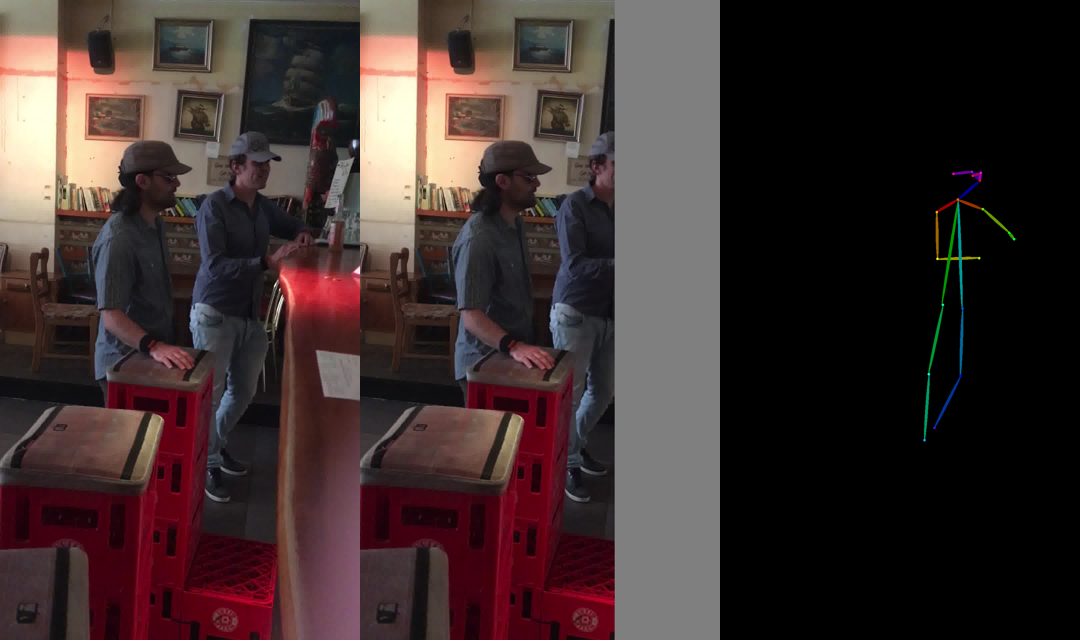

In [13]:
width, height = int(batch['K_fullimg'][0,0,2].item() * 2), int(batch['K_fullimg'][0,1,2].item() * 2)
bbox, direction = mask_bbox_from_keypoints(batch['kp2d'][i].numpy(), (width, height), 0.8)
print(bbox, direction)

canvas, mask = apply_bbox_mask(target_frame, bbox, direction)
Image.fromarray(np.concatenate([
    np.asarray(target_frame.resize((width//3, height//3))),
    np.asarray(canvas.resize((width//3, height//3))),
    np.asarray(control_frame.resize((width//3, height//3))),
], axis=1))

  0%|          | 0/50 [00:00<?, ?it/s]

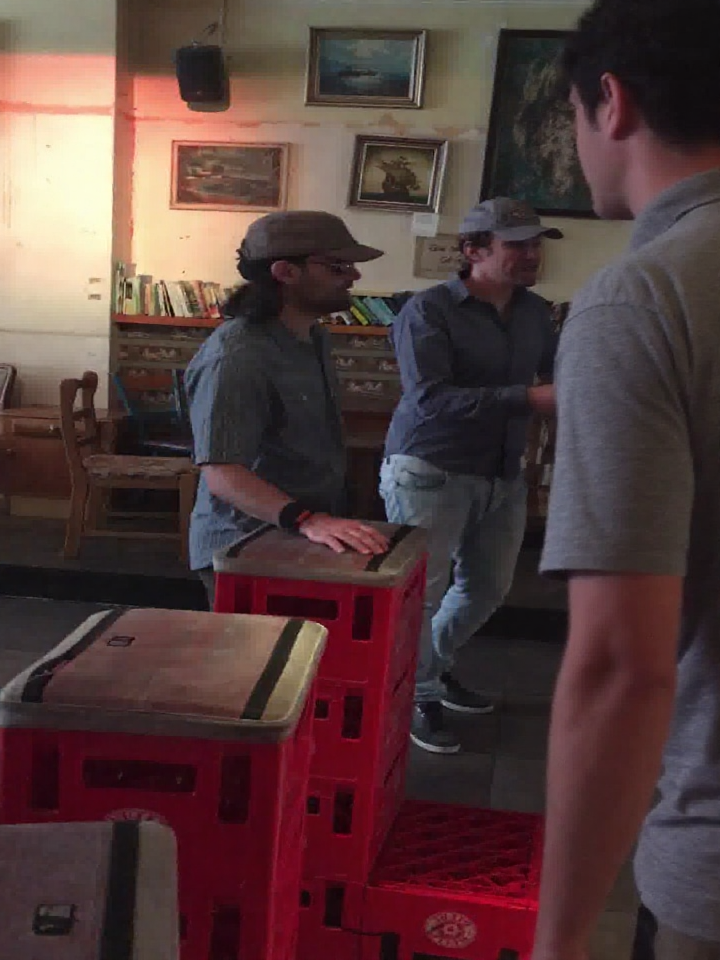

: 

In [ ]:
# t_w, t_h = width // 2, height // 2
t_w, t_h = 544, 960
image = pipe(
    prompt="Full-bodied human",
    image=target_frame.resize((t_w, t_h)),
    mask_image=mask.resize((t_w, t_h)),
    # control_image=control_frame.resize((t_w, t_h)),
    height=t_h,
    width=t_w,
    strength=1.0,
    guidance_scale=28.,
    # controlnet_conditioning_scale=1.0,
    num_inference_steps=50,
    # control_guidance_start=0.0,
    # control_guidance_end=1.0,
    # num_inference_steps=50,
    # max_sequence_length=512,
).images[0]
image